# Ejercicios de Seaborn

# 1. Importa pandas, pyplot y seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Lee 'Pokemon.csv', lee la primera columna del csv como índice del DataFrame

In [3]:
import os
os.getcwd()

'/Users/andoni/2026-02-BILBAO-FT-Data-Science/2-Data_Analysis/6-Visualización/2-Seaborn/Ejercicios'

In [8]:
df = pd.read_csv("/Users/andoni/2026-02-BILBAO-FT-Data-Science/2-Data_Analysis/6-Visualización/2-Seaborn/Ejercicios/data/Pokemon.csv", index_col=0)

# 4. Mira las primeras filas del dataset para hacerte una idea de los datos cargados

In [9]:
df.head()

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Stage,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False


# 5. Haz un scatter plot con lmplot(), que es el método que pinta una regresión lineal
### Pasa el DataFrame como argumento del método en el parámetro llamado data

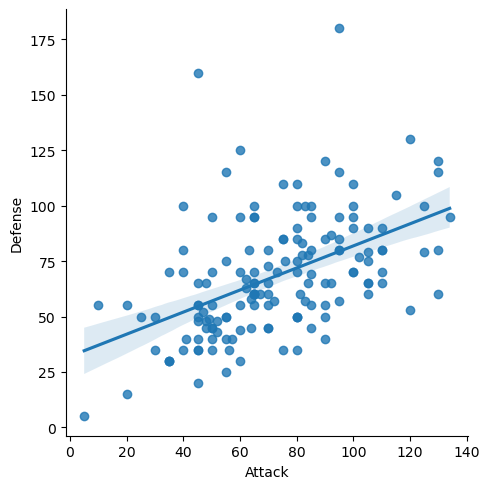

In [10]:
# sns.lmplot() dibuja un scatter plot (puntos sueltos) + una línea de regresión lineal
# x="Attack" → la columna Attack va en el eje horizontal
# y="Defense" → la columna Defense va en el eje vertical
# data=df → los datos salen del DataFrame df
# La línea de regresión es una recta que intenta "ajustarse" a los puntos,
# para ver si hay tendencia: ¿más ataque = más defensa?
sns.lmplot(x="Attack", y="Defense", data=df)

# 6. No queremos ver la línea recta de la regresión lineal.
### prueba a añadir fit_reg a falso

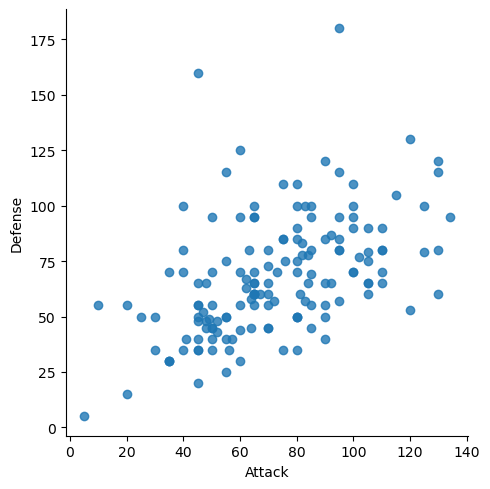

In [11]:
# fit_reg=False → "no dibujes la línea de regresión, solo los puntos"
# fit_reg viene de "fit regression" (ajustar regresión)
# Al ponerlo en False, obtenemos un scatter plot limpio
sns.lmplot(x="Attack", y="Defense", data=df, fit_reg=False)

# 7. Vamos a decir qué variable (columna del DataFrame) codifica los colores (hue)
### Que el hue sea el Stage

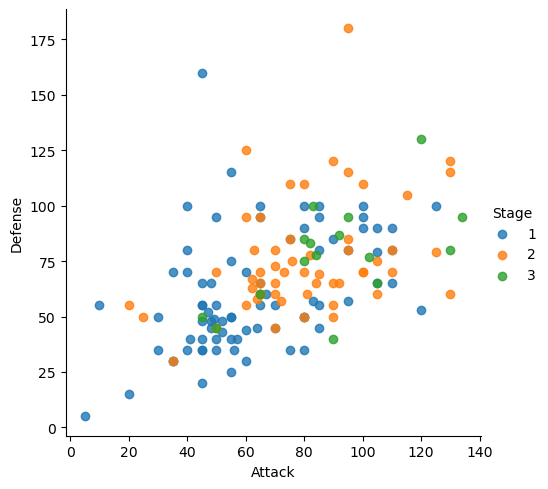

In [14]:
# hue="Stage" → colorea cada punto según el valor de la columna "Stage"
# Stage tiene valores 1, 2 y 3 (las 3 fases de evolución de un Pokémon)
# Seaborn asigna un color diferente a cada valor y crea la leyenda automáticamente
# "hue" en inglés = "tono/matiz de color"
# En Seaborn, hue SIEMPRE significa "la variable que decide el color de cada punto"

sns.lmplot(x="Attack", y="Defense", data=df, fit_reg=False, hue="Stage")

# 8. Limita el eje x entre 20 y 100

(20.0, 100.0)

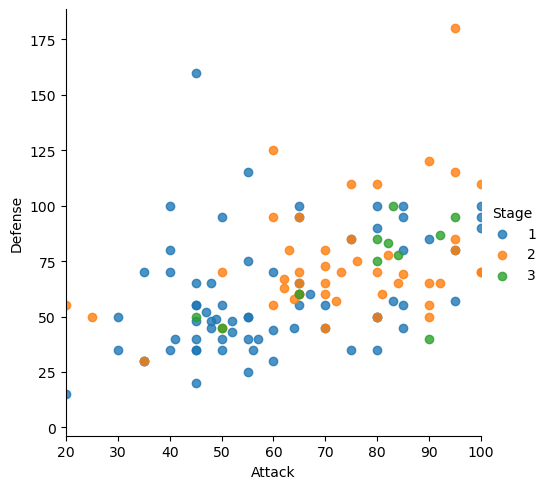

In [ ]:
# Primero dibujamos el mismo gráfico que antes (scatter coloreado por Stage)
sns.lmplot(x="Attack", y="Defense", data=df, fit_reg=False, hue="Stage")

# Después usamos plt.xlim() de Matplotlib para recortar el eje X (IMPORTANTE; estamos usando una función de Matplotlib)
# Solo se verán los puntos con Attack entre 20 y 100
# Esto demuestra algo importante: Seaborn dibuja, pero Matplotlib personaliza (corta datos?!)
plt.xlim(20, 100)

# 9. Dibuja un diagrama de cajas con el dataframe

<Axes: >

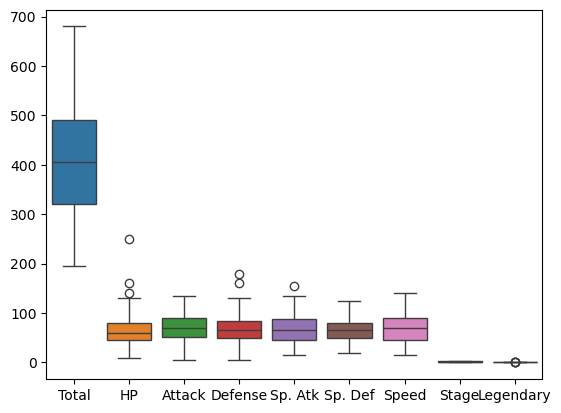

In [16]:
# sns.boxplot() dibuja un diagrama de cajas para CADA columna numérica del DataFrame
# data=df → le pasamos el DataFrame entero
# Cada "caja" representa cómo se distribuyen los valores de una columna:
#   - La línea del medio = mediana (el valor que está justo en la mitad)
#   - Los bordes de la caja = percentil 25 y 75 (el 50% central de los datos)
#   - Las "patitas" (whiskers) = se extienden hasta 1.5 veces el tamaño de la caja
#   - Los puntos sueltos fuera = outliers (valores raros/extremos)
sns.boxplot(data=df)

# 10. No nos interesan las columnas Total, Stage ni Legendary
### Bórralos del DataFrame y vuelve a dibujar el diagrama de cajas

<Axes: >

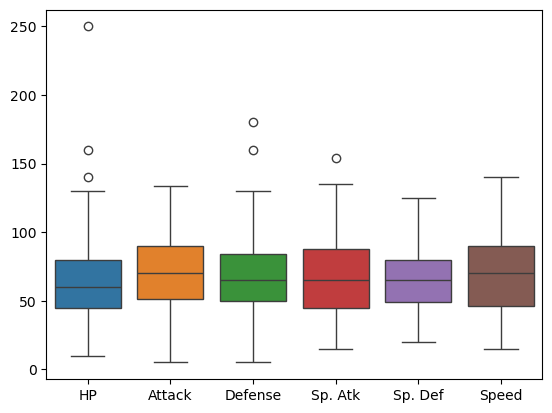

In [17]:
# Eliminamos las columnas que no nos interesan para el boxplot:
# - "Total" es la suma de todas las stats → no aporta info nueva, y además
#   tiene valores mucho más altos que distorsionan la escala del gráfico
# - "Stage" es 1, 2 o 3 → no es una stat de combate
# - "Legendary" es True/False → no es numérica de combate
# drop() elimina columnas; columns=[...] le dice cuáles borrar
df_clean = df.drop(columns=["Total", "Stage", "Legendary"])

# Ahora el boxplot solo muestra HP, Attack, Defense, Sp. Atk, Sp. Def y Speed
# Que son las 6 estadísticas de combate reales de cada Pokémon
sns.boxplot(data=df_clean)

# 11. Mira cuántos 'Type 1' diferentes hay en el DataFrame

In [20]:
t1_diferentes = df["Type 1"].nunique() 
print(f"Hay {t1_diferentes} Type 1 diferentes en el DataFrame")

Hay 15 Type 1 diferentes en el DataFrame


# 12. Quédate del Dataframe solo con los 'Type 1' iguales a 'Grass', 'Fire' o 'Water'

In [24]:
# Filtramos el DataFrame para quedarnos SOLO con los Pokémon cuyo Type 1
# sea Grass, Fire o Water
# .isin() devuelve True cuando el valor de la columna está en la lista que le pasamos
# Es como decir: "¿este Pokémon es de tipo Grass O Fire O Water?"
# Solo las filas donde eso sea True se quedan en el nuevo DataFrame
df_gfw = df_clean[df_clean["Type 1"].isin(["Grass", "Fire", "Water"])]
df_gfw

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
#,,,,,,,,,
1,Bulbasaur,Grass,Poison,45,49,49,65,65,45
2,Ivysaur,Grass,Poison,60,62,63,80,80,60
3,Venusaur,Grass,Poison,80,82,83,100,100,80
4,Charmander,Fire,NaN,39,52,43,60,50,65
5,Charmeleon,Fire,NaN,58,64,58,80,65,80
6,Charizard,Fire,Flying,78,84,78,109,85,100
7,Squirtle,Water,NaN,44,48,65,50,64,43
8,Wartortle,Water,NaN,59,63,80,65,80,58
9,Blastoise,Water,NaN,79,83,100,85,105,78


# 13. Usa un estilo 'whitegrid'

<Axes: >

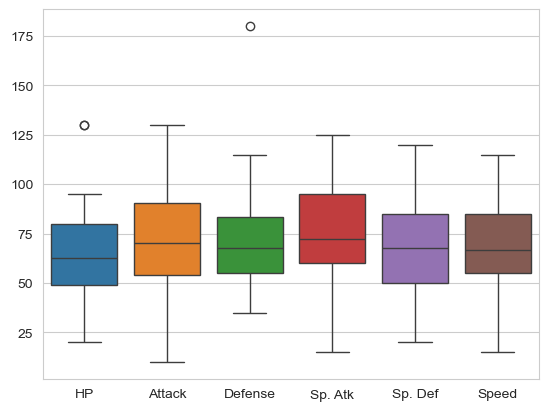

In [26]:
# Cambiamos el estilo visual de Seaborn a "whitegrid"
# whitegrid = fondo blanco con líneas de cuadrícula suaves
# Es el estilo más limpio y profesional para presentaciones
# Otros estilos: "darkgrid", "white", "dark", "ticks"
sns.set_style("whitegrid")

# Aplicamos el estilo whitegrid
sns.set_style("whitegrid")

# Cualquier gráfico que hagamos DESPUÉS ya usa el nuevo estilo
# Repetimos el boxplot del ejercicio anterior para comprobarlo
sns.boxplot(data=df_gfw)

# 14. Pinta diagramas de violín con el DataFrame filtrado por los 3 tipos

<Axes: xlabel='Type 1', ylabel='Attack'>

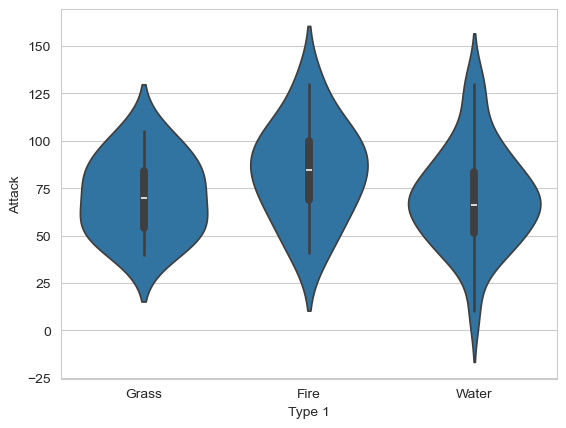

In [27]:
# sns.violinplot() dibuja un "violín" para cada categoría
# Es como un boxplot PERO muestra la FORMA de la distribución
#   - Las partes anchas del violín = donde hay MUCHOS datos
#   - Las partes estrechas = donde hay POCOS datos
# x="Type 1" → en el eje X ponemos el tipo (Grass, Fire, Water)
# y="Attack" → en el eje Y ponemos el valor de Attack
# data=df_gfw → usamos el DataFrame filtrado (solo los 3 tipos)
sns.violinplot(x="Type 1", y="Attack", data=df_gfw)

# 15. Escribe una lista de colores con valores '#78C850', '#F08030',  '#6890F0'

In [ ]:
# Gracias a CLAUDE AI 
# Creamos una lista con 3 colores hexadecimales (los colores clásicos de los juegos Pokémon)
# "#78C850" = verde → Grass 
# "#F08030" = naranja → Fire
# "#6890F0" = azul → Water
pkmn_colors = ["#78C850", "#F08030", "#6890F0"]

# 16. Pinta de nuevo los diagramas de violín añadiendo esos colores en la paleta (palette)

/var/folders/05/p9fdjn250m3cnygsqvhztskw0000gn/T/ipykernel_9567/3246518558.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors)


<Axes: xlabel='Type 1', ylabel='Attack'>

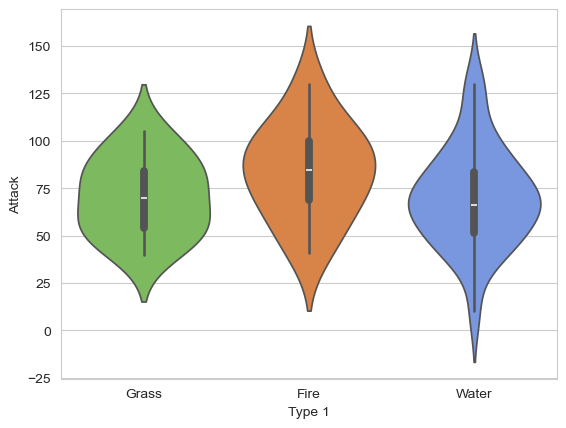

In [29]:
# palette= acepta una lista de colores
# Seaborn asigna cada color a cada categoría EN ORDEN:
#   - Primer color (#78C850 verde) → primera categoría que aparezca
#   - Segundo color (#F08030 naranja) → segunda categoría
#   - Tercer color (#6890F0 azul) → tercera categoría
sns.violinplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors)

# 17. Con el diagrama de violín vemos la forma de la distribución, pero no sabemos si Grass tiene muchos puntos y Fire tiene muy pocos.
### Para ver esto, usamos el swarmplot.
### Pinta el último diagrama de violines pero con un swarmplot en lugar de un violin

/var/folders/05/p9fdjn250m3cnygsqvhztskw0000gn/T/ipykernel_9567/3649894380.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors)


<Axes: xlabel='Type 1', ylabel='Attack'>

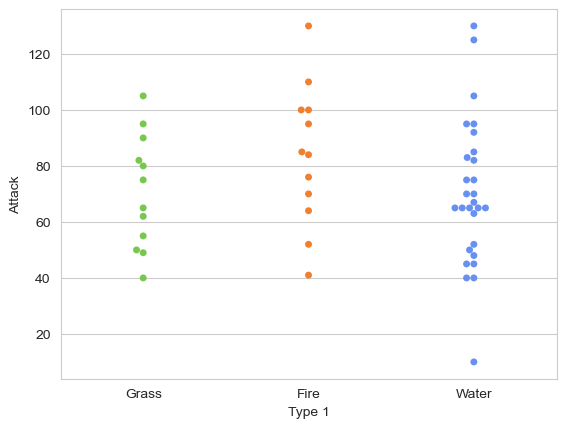

In [33]:
# sns.swarmplot() dibuja CADA PUNTO INDIVIDUAL, separándolos para que no se solapen
# La ventaja frente al violín: ves CUÁNTOS datos hay realmente
# Si Grass tiene 70 Pokémon y Fire tiene 52, lo notas porque
# la "columna" de puntos de Grass será más larga
# El violín no te deja ver eso porque "normaliza" la forma
sns.swarmplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors)

<Axes: xlabel='Type 1', ylabel='Attack'>

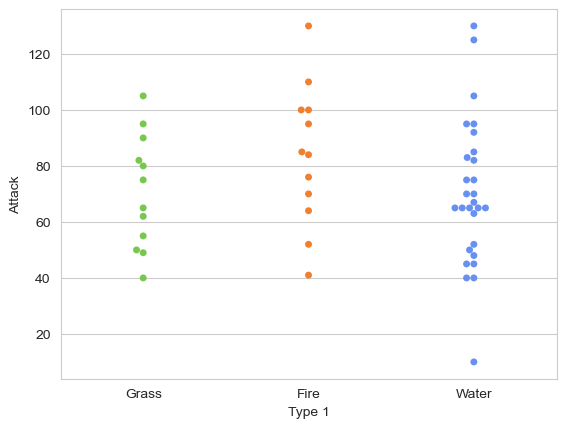

In [ ]:
sns.swarmplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors, hue="Type 1", legend=False)
# Sin que esté deprecado en el futuro 


# 18. Queremos ver los violines a la vez que los swarm, los podemos pintar juntos. 
### Elimina los diagramas de caja dentro de los violines con el parámetro inner = None y pon una transparencia de 0.9 en el swarmplot
### Pon un título con pyplot (como siempre)

/var/folders/05/p9fdjn250m3cnygsqvhztskw0000gn/T/ipykernel_9567/4116896069.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors, inner=None)
/var/folders/05/p9fdjn250m3cnygsqvhztskw0000gn/T/ipykernel_9567/4116896069.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors, alpha=0.9)


Text(0.5, 1.0, 'Attack by Type: Violin + Swarm')

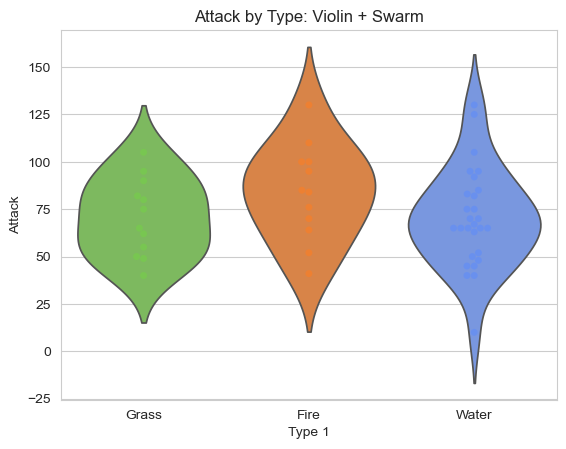

In [40]:
# Llamamos PRIMERO al violín (la forma de fondo)
# inner=None → elimina la mini-caja que sale por defecto DENTRO del violín
#   (así el violín queda limpio y no interfiere con los puntos del swarm)
sns.violinplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors, inner=None)

# Llamamos DESPUÉS al swarm (los puntos se dibujan ENCIMA del violín)
# alpha=0.9 → los puntos son ligeramente transparentes (1=opaco, 0=invisible)
#   así se ve un poco del violín detrás de cada punto
sns.swarmplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors, alpha=0.9) 

# Ponemos título usando plt (Matplotlib), como siempre
# Esto demuestra que Seaborn y Matplotlib conviven perfectamente
plt.title("Attack by Type: Violin + Swarm")

/var/folders/05/p9fdjn250m3cnygsqvhztskw0000gn/T/ipykernel_9567/1130943866.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors, inner=None)


Text(0.5, 1.0, 'Attack by Type: Violin + Swarm')

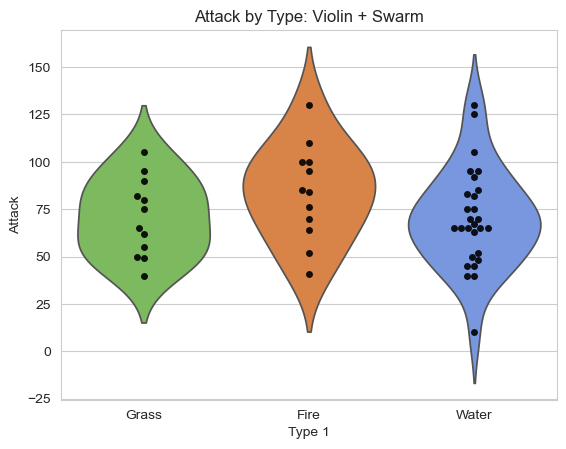

In [39]:
# Llamamos PRIMERO al violín (la forma de fondo)
# inner=None → elimina la mini-caja que sale por defecto DENTRO del violín
#   (así el violín queda limpio y no interfiere con los puntos del swarm)
sns.violinplot(x="Type 1", y="Attack", data=df_gfw, palette=pkmn_colors, inner=None)

# Llamamos DESPUÉS al swarm (los puntos se dibujan ENCIMA del violín)
# alpha=0.9 → los puntos son ligeramente transparentes (1=opaco, 0=invisible)
#   así se ve un poco del violín detrás de cada punto
sns.swarmplot(x="Type 1", y="Attack", data=df_gfw, color="Black", alpha=0.9) # aquí por defecto hubiera puesto paletter=pkmn_colors 
# pero pongo color="Black" para que se vean los puntos si no, no se ven

# Ponemos título usando plt (Matplotlib), como siempre
# Esto demuestra que Seaborn y Matplotlib conviven perfectamente
plt.title("Attack by Type: Violin + Swarm")

# 19. Veamos la función melt() de pandas. Melt toma los valores de varias columnas y los junta todos en una misma columna nueva.
### Dado un DataFrame, melt recibe varios parámetros:
### * qué columnas del DataFrame se quedan igual
### * qué nombres de columnas del dataframe pasan a ser una columna nueva
### * cómo queremos llamar esas nuevas columnas

### Primero recuerda el Dataframe df_grass_fire_water con las primeras 5 filas

In [41]:
df_gfw.head()

,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
#,,,,,,,,,
1,Bulbasaur,Grass,Poison,45,49,49,65,65,45
2,Ivysaur,Grass,Poison,60,62,63,80,80,60
3,Venusaur,Grass,Poison,80,82,83,100,100,80
4,Charmander,Fire,NaN,39,52,43,60,50,65
5,Charmeleon,Fire,NaN,58,64,58,80,65,80


# 20. Queremos dejar igual las variables 'Name' y 'Type 1'
### Queremos añadir una columa nueva cuyos valores sean las columnas que queremos apilar y que se llame 'New Column'
### Escribimos df_gfw.melt(id_vars=['Name', 'Type 1'], value_vars=[...], var_name='New Column')

In [45]:
# melt() "DERRITE" un DataFrame ancho y lo convierte en uno largo - GRACIAS CLAUDE AI
# 
# ANTES (ancho): cada stat es una COLUMNA
#   Name         Type 1   Attack   Defense   Speed
#   Bulbasaur    Grass    49       49        45
#
# DESPUÉS (largo): todas las stats se apilan en UNA sola columna
#   Name         Type 1   New Column   value
#   Bulbasaur    Grass    Attack       49
#   Bulbasaur    Grass    Defense      49
#   Bulbasaur    Grass    Speed        45
#
# id_vars → columnas que se QUEDAN IGUAL (se repiten en cada fila)
# value_vars → columnas que se APILAN (sus nombres van a "New Column", sus valores a "value")
# var_name → cómo queremos llamar a la nueva columna que contiene los nombres
df_melted = df_gfw.melt(
    id_vars=["Name", "Type 1"],
    value_vars=["Attack", "Defense", "Speed", "HP", "Sp. Atk", "Sp. Def"],
    var_name="New Column"
)

df_melted

,Name,Type 1,New Column,value
0,Bulbasaur,Grass,Attack,49
1,Ivysaur,Grass,Attack,62
2,Venusaur,Grass,Attack,82
3,Charmander,Fire,Attack,52
4,Charmeleon,Fire,Attack,64
...,...,...,...,...
307,Gyarados,Water,Sp. Def,100
308,Lapras,Water,Sp. Def,95
309,Vaporeon,Water,Sp. Def,95
310,Flareon,Fire,Sp. Def,110


# 21. Pintamos el swarmplot con el melted y entendemos la información

<Axes: xlabel='New Column', ylabel='value'>

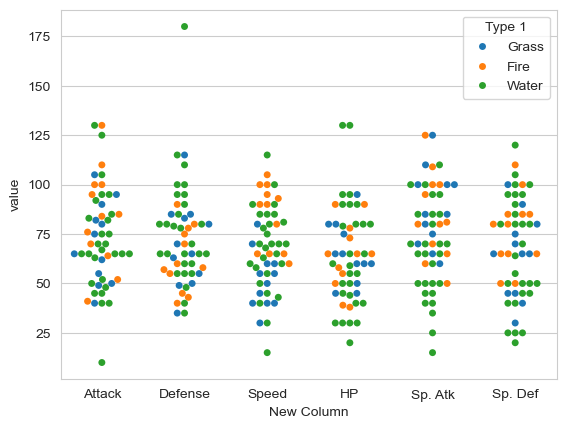

In [46]:
# Ahora en el eje X tenemos los NOMBRES de las stats (Attack, Defense, Speed...)
# En el eje Y tenemos los VALORES numéricos
# hue="Type 1" → colorea cada punto según el tipo (Grass, Fire, Water)
# Así vemos de un vistazo cómo se comparan los 3 tipos en TODAS las stats a la vez
sns.swarmplot(x="New Column", y="value", hue="Type 1", data=df_melted)

In [ ]:
# Hasta el ejercicio 16, el eje X era "Type 1" y la palette se asignaba en orden:
#   primer grupo (Grass) → primer color (#78C850 verde)
#   segundo grupo (Fire) → segundo color (#F08030 naranja)
#   tercero (Water) → tercer color (#6890F0 azul)
# Coincidían porque X y los colores seguían el mismo orden.
#
# Ahora el eje X es "New Column" (Attack, Defense, Speed...),
# y los 3 tipos están MEZCLADOS dentro de cada categoría del eje X.
# Sin palette, Seaborn usa sus colores por defecto (azul, naranja, verde de Seaborn)
# que NO son los colores Pokémon.
# Por eso hay que pasar palette= explícitamente para forzar los colores correctos.

<Axes: xlabel='New Column', ylabel='value'>

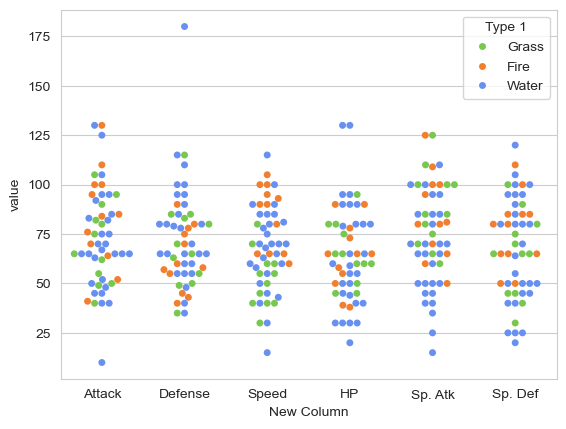

In [ ]:
sns.swarmplot(x="New Column", y="value", hue="Type 1", data=df_melted, palette=pkmn_colors) # Aquí está bien

# 22. Basándote en el gráfico anterior, define el tamaño de la figura en (10,6) (usa plt)
### En el swarmplot añade el argumento dodge a True y usa la anterior paleta de colores Pokemon

### Dodge en inglés es "esquivar", ¿qué diferencia ves?

## Usando plt 
### fija el límite del eje Y entre 0 y 200
### fija la leyenda con bbox_to_anchor en upper left. Pista: upper left es el código 2 y se usa el parámetro loc.

### Observa que incluso usando Seaborn, usamos Pyplot para trabajar con los ejes, la leyenda y el tamaño
### Lo importante es que Seaborn y Pyplot conviven bien juntos

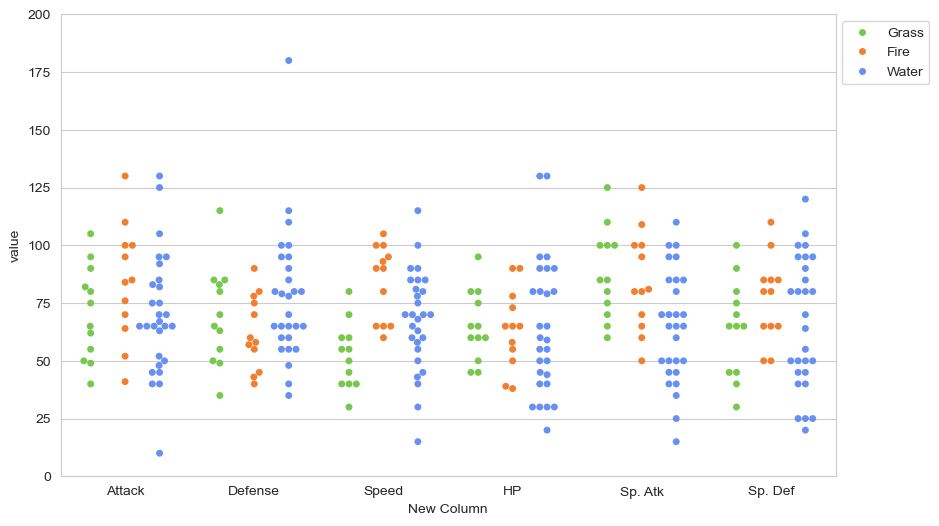

In [48]:
# plt.figure(figsize=(10, 6)) → creamos una figura más grande
# 10 pulgadas de ancho, 6 de alto, para que quepan bien todos los puntos
plt.figure(figsize=(10, 6))

# dodge=True → SEPARA los puntos de cada tipo en columnas diferentes
#   Sin dodge: los 3 tipos se mezclan en la misma posición X
#   Con dodge: se "esquivan" (dodge = esquivar) y aparecen lado a lado
# palette=pkmn_colors → usamos nuestros colores Pokémon personalizados
sns.swarmplot(x="New Column", y="value", hue="Type 1", data=df_melted,
              dodge=True, palette=pkmn_colors)

# Fijamos el eje Y entre 0 y 200 para que todas las stats se vean bien
plt.ylim(0, 200)

# plt.legend() crea la leyenda
# bbox_to_anchor=(1, 1) → posiciona la leyenda en las coordenadas (1,1)
#   que es la esquina superior derecha del gráfico
# loc=2 → código numérico de "upper left", indica QUÉ ESQUINA de la caja
#   de la leyenda se ancla en ese punto (la esquina superior izquierda de la leyenda
#   se pone en la esquina superior derecha del gráfico → la leyenda queda fuera)
plt.legend(bbox_to_anchor=(1, 1), loc=2)

# 23. Mapas de calor
### Calcula las correlaciones del primer DataFrame original df
### Pista: las correlaciones se calculan con el método corr()
### Recuerda: las correlaciones miden entre dos variables, si varío una, cuánto me varía la otra (cómo están de relacionadas)

<Axes: >

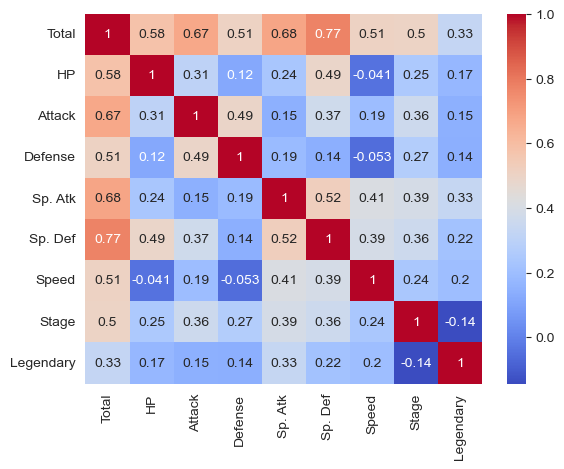

In [50]:
# .corr() calcula la CORRELACIÓN entre todas las columnas numéricas
# La correlación es un número entre -1 y 1:
#   +1 = cuando una variable sube, la otra SIEMPRE sube igual → relación perfecta positiva
#   -1 = cuando una sube, la otra SIEMPRE baja → relación perfecta negativa
#   0 = no hay relación, se mueven de forma independiente
# numeric_only=True → solo calcula para columnas numéricas (ignora Name, Type, etc.)
# La "autocorrelación" (una variable consigo misma) siempre es 1.0 → obvio, es perfecta
corr = df.corr(numeric_only=True)

# sns.heatmap() dibuja la tabla de correlaciones como un MAPA DE CALOR
# Los colores representan los valores: colores intensos = correlación fuerte
# annot=True → escribe el NÚMERO dentro de cada casilla
sns.heatmap(corr, annot=True, cmap="coolwarm")

### ¿la correlación entre qué valores se encuentra?
### la autocorrelación es la correlación de una variable consigo misma, ¿qué aprecias?
### Encuentra dos variables que veas que están fuertemente relacionadas según la correlación

# 24. Pinta el histograma y la densidad de probabilidad del nivel de defensa usando el DataFrame original

<Axes: xlabel='Defense', ylabel='Count'>

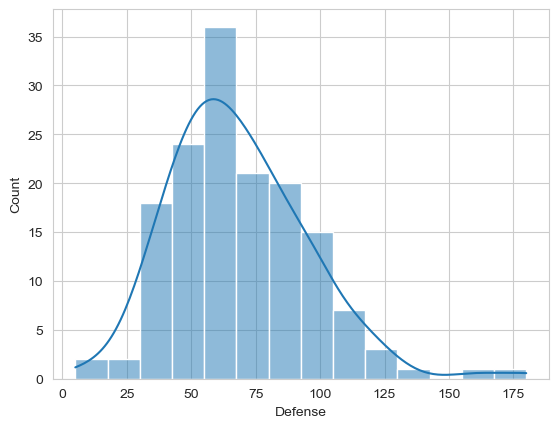

In [51]:
# sns.histplot() dibuja un histograma de la columna Defense
# Las barras cuentan cuántos Pokémon tienen cada rango de Defense
# kde=True → superpone una curva de densidad suave encima del histograma
#   KDE = Kernel Density Estimation = una forma de "suavizar" el histograma
#   En vez de barras escalonadas, te da una curva continua que muestra
#   la forma general de la distribución
sns.histplot(df["Defense"], kde=True)

# 25. Pinta un diagrama de barras de la columna 'Type 1' usando el DataFrame original
### Usa un sns.countplot
### Usa plt.xticks y gira las etiquetas

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Grass'),
  Text(1, 0, 'Fire'),
  Text(2, 0, 'Water'),
  Text(3, 0, 'Bug'),
  Text(4, 0, 'Normal'),
  Text(5, 0, 'Poison'),
  Text(6, 0, 'Electric'),
  Text(7, 0, 'Ground'),
  Text(8, 0, 'Fairy'),
  Text(9, 0, 'Fighting'),
  Text(10, 0, 'Psychic'),
  Text(11, 0, 'Rock'),
  Text(12, 0, 'Ghost'),
  Text(13, 0, 'Ice'),
  Text(14, 0, 'Dragon')])

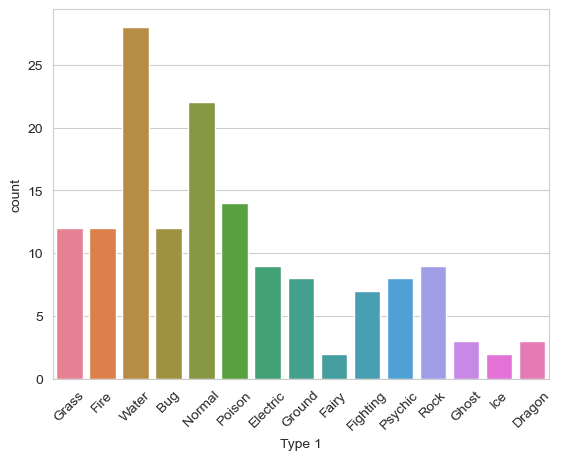

In [ ]:
# sns.countplot() CUENTA automáticamente cuántos Pokémon hay de cada tipo
# No necesitamos calcular nada: Seaborn cuenta las ocurrencias por ti
# x="Type 1" → cada barra es un tipo diferente
# data=df → usamos el DataFrame original completo (los 18 tipos)
# hue="Type 1" → colorea cada barra según el tipo (un color diferente por tipo)
# legend=False → no mostramos la leyenda (no aporta info extra, ya están los nombres en X)
sns.countplot(x="Type 1", data=df, hue="Type 1", legend=False)

# plt.xticks(rotation=45) → rota las etiquetas del eje X 45 grados
# Necesario porque hay 18 tipos y los nombres son largos → si no se rotan, se solapan
plt.xticks(rotation=45)

# 26. Usa catplot con el DataFrame original.
### Muestra el valor de Defense según el 'Type 1', muestra un subplot para legendarios y otro para no legendarios y divide los colores según el Type 2

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'Grass'),
  Text(1, 0, 'Fire'),
  Text(2, 0, 'Water'),
  Text(3, 0, 'Bug'),
  Text(4, 0, 'Normal'),
  Text(5, 0, 'Poison'),
  Text(6, 0, 'Electric'),
  Text(7, 0, 'Ground'),
  Text(8, 0, 'Fairy'),
  Text(9, 0, 'Fighting'),
  Text(10, 0, 'Psychic'),
  Text(11, 0, 'Rock'),
  Text(12, 0, 'Ghost'),
  Text(13, 0, 'Ice'),
  Text(14, 0, 'Dragon')])

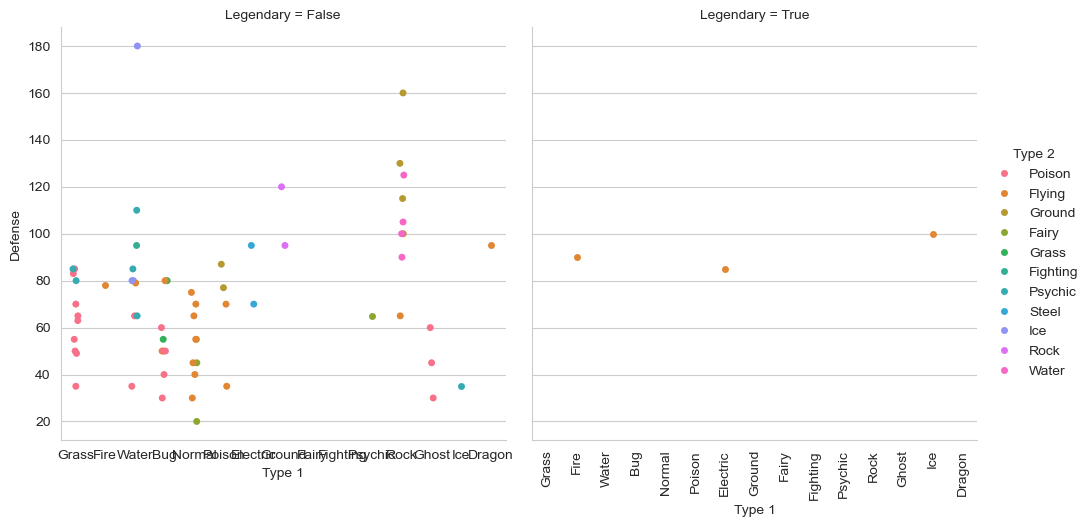

In [53]:
# sns.catplot() es la función MÁS VERSÁTIL de Seaborn para gráficos categóricos - Gracias Claude AI 
# x="Type 1" → en el eje X ponemos el tipo principal
# y="Defense" → en el eje Y ponemos la defensa
# data=df → usamos el DataFrame original
# hue="Type 2" → el COLOR de cada punto lo decide el Type 2 (tipo secundario)
# col="Legendary" → crea DOS SUBGRÁFICOS lado a lado:
#   uno para Legendary=False (normales) y otro para Legendary=True (legendarios)
#   Así puedes comparar la defensa de los normales vs los legendarios
sns.catplot(x="Type 1", y="Defense", data=df, hue="Type 2", col="Legendary")

# Rotamos las etiquetas porque los 18 nombres de tipos son muy largos
plt.xticks(rotation=90)

# 27. Muestra una función distribución de probabilidad con kdeplot (curvas de nivel) de la defensa respecto al ataque.
### Di un bin 2D donde caigan muchos puntos (ataque, defensa).

<Axes: xlabel='Attack', ylabel='Defense'>

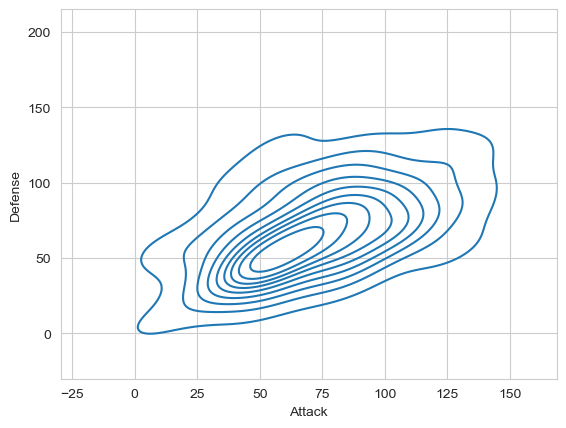

In [54]:
# sns.kdeplot() con DOS variables (x e y) dibuja CURVAS DE NIVEL
# Es como un mapa topográfico: los círculos más internos = más datos concentrados
# x="Attack" → eje horizontal
# y="Defense" → eje vertical
# data=df → DataFrame original
# Las zonas con más círculos = donde hay más Pokémon
sns.kdeplot(x="Attack", y="Defense", data=df)

# 28. Pinta una distribución de probabilidad conjunta con jointplot, pintando la defensa respecto al ataque del DataFrame original

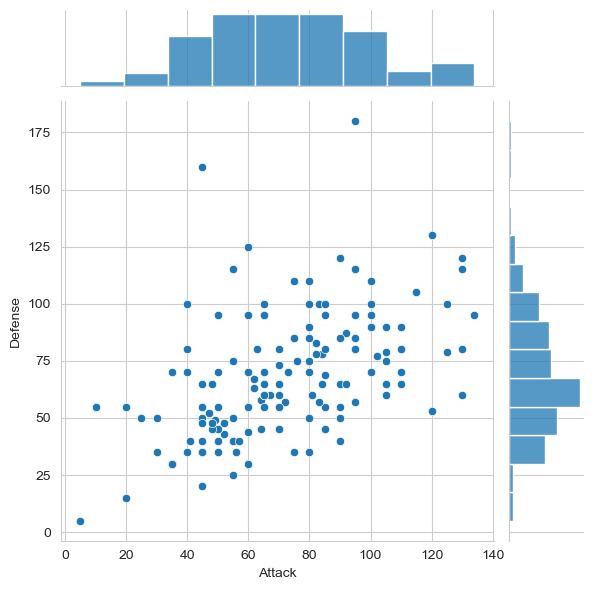

In [55]:
# sns.jointplot() es un "todo en uno":
#   - En el CENTRO: un scatter plot de Attack vs Defense
#   - ARRIBA: un histograma solo de Attack
#   - A la DERECHA: un histograma solo de Defense
# Así ves la RELACIÓN entre las dos variables Y la DISTRIBUCIÓN de cada una
# Es perfecto para exploración rápida de datos
sns.jointplot(x="Attack", y="Defense", data=df)